#1. Extraccion de datos

In [13]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import json_normalize

# Configuración de estilo para las gráficas
sns.set_theme(style="whitegrid")

# URL de la API (versión raw para lectura directa)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Extraer datos
response = requests.get(url)
if response.status_code == 200:
    data = response.json()
    # Normalizamos el JSON para "aplanar" los diccionarios internos
    df = json_normalize(data)
    print("✅ Extracción exitosa. El dataset tiene", df.shape[0], "filas y", df.shape[1], "columnas.")
else:
    print(f"❌ Error al extraer: {response.status_code}")

✅ Extracción exitosa. El dataset tiene 7267 filas y 21 columnas.


#2. Transformacion de datos

In [14]:
# --- Conocer el conjunto de datos ---
# Simplificamos los nombres de las columnas (quitamos los prefijos 'customer.', 'phone.', etc.)
df.columns = [col.split('.')[-1] for col in df.columns]

# --- Comprobación de incoherencias ---
# 1. Verificamos tipos de datos originales
print("Tipos de datos iniciales:")
print(df.dtypes)

# 2. Identificar valores únicos en Churn para ver consistencia
print("\nValores únicos en Churn:", df['Churn'].unique())

# --- Manejo de inconsistencias ---
# A. Convertir 'Total' a numérico (importante: errores='coerce' vuelve nulos los espacios vacíos)
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# B. Tratar valores nulos (Clientes con tenure=0 no tienen Total cargado aún)
df['Total'] = df['Total'].fillna(0)

# C. Eliminar duplicados si existen
duplicados = df.duplicated().sum()
df = df.drop_duplicates()
print(f"\nSe eliminaron {duplicados} filas duplicadas.")

# D. Estandarizar textos (opcional pero recomendado: quitar espacios extra)
df['PaymentMethod'] = df['PaymentMethod'].str.strip()

print("\n✅ Transformación completada.")

Tipos de datos iniciales:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Monthly             float64
Total                object
dtype: object

Valores únicos en Churn: ['No' 'Yes' '']

Se eliminaron 0 filas duplicadas.

✅ Transformación completada.


#3. CARGA Y ANALISIS


In [15]:
# ANALISIS DESCRIPTIVO
print("Análisis Descriptivo:")
display(df.describe())

Análisis Descriptivo:


,SeniorCitizen,tenure,Monthly,Total
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2277.182035
std,0.369074,24.571773,30.129572,2268.648587
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.425000,396.200000
50%,0.000000,29.000000,70.300000,1389.200000
75%,0.000000,55.000000,89.875000,3778.525000
max,1.000000,72.000000,118.750000,8684.800000


/tmp/ipykernel_255/3532823022.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='magma')


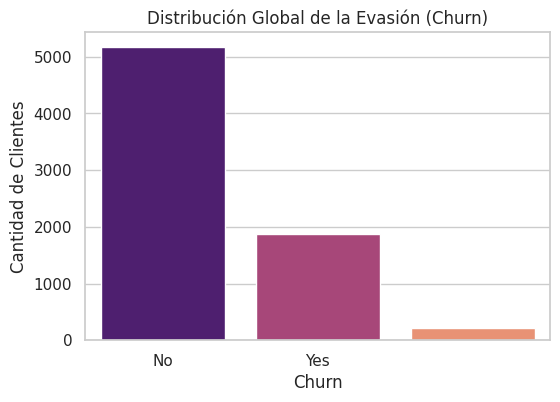

Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [16]:
# DISTRIBUCION DE EVASION


plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='magma')
plt.title('Distribución Global de la Evasión (Churn)')
plt.ylabel('Cantidad de Clientes')
plt.show()

print(df['Churn'].value_counts(normalize=True) * 100)

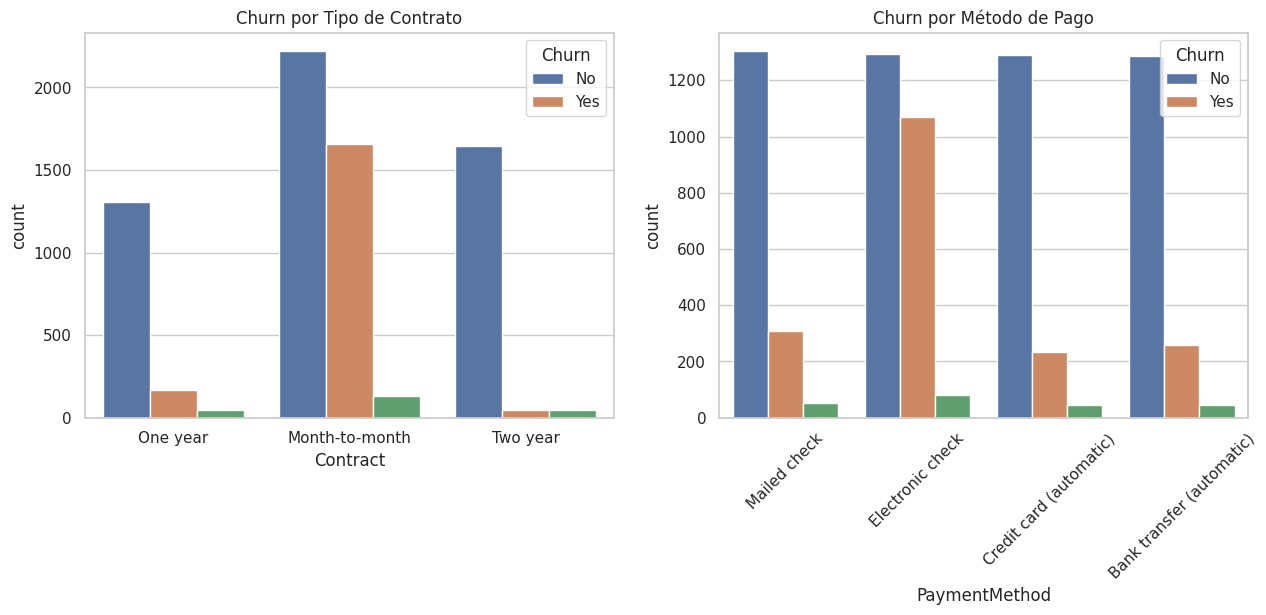

In [17]:
# evasion por variables categoricas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0])
axes[0].set_title('Churn por Tipo de Contrato')

sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1])
axes[1].set_title('Churn por Método de Pago')
plt.xticks(rotation=45)

plt.show()

/tmp/ipykernel_255/1674990478.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


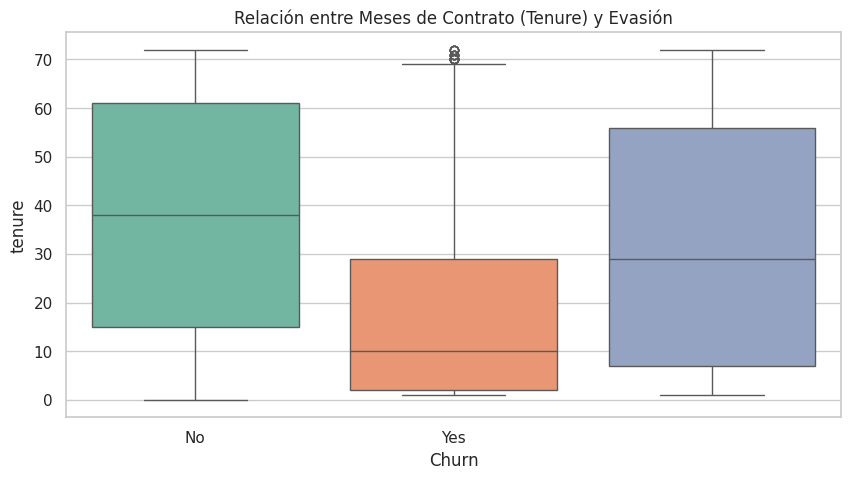

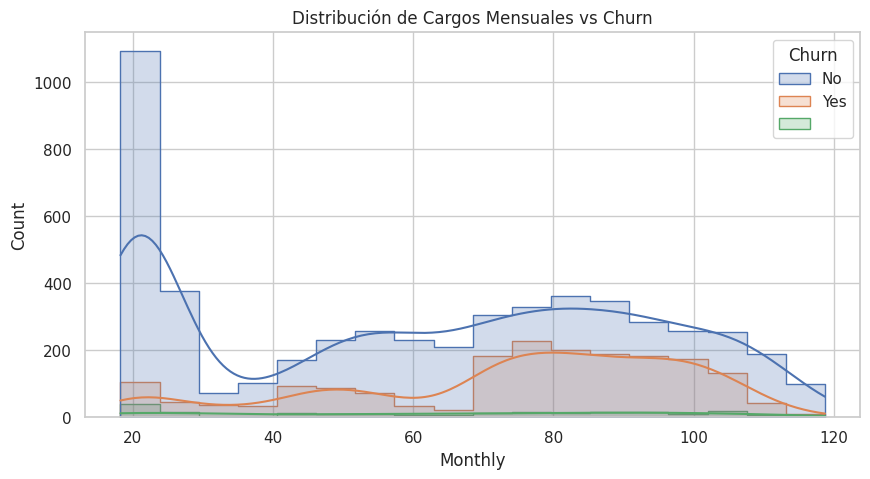

In [18]:
#CONTEO DE EVASION POR VARIABLES NUMERICAS

plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Relación entre Meses de Contrato (Tenure) y Evasión')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Monthly', hue='Churn', kde=True, element="step")
plt.title('Distribución de Cargos Mensuales vs Churn')
plt.show()

In [20]:


informe = """
################################################################################
#                          INFORME FINAL: TELECOM X                            #
#                      ANÁLISIS DE EVASIÓN DE CLIENTES                         #
################################################################################

1. INTRODUCCIÓN
El objetivo de este proyecto fue analizar el dataset de Telecom X para identificar
los factores que impulsan la evasión de clientes (Churn). La empresa enfrenta
una alta tasa de cancelaciones y requiere información estratégica.

2. LIMPIEZA Y TRATAMIENTO DE DATOS (ETL)
- Extracción: Datos consumidos desde API JSON de GitHub.
- Transformación: Se normalizaron estructuras anidadas (customer, phone, internet, account).
- Tipos de Datos: Se corrigió la columna 'Total' de texto a float64.
- Consistencia: Se eliminaron prefijos de columnas y se gestionaron valores nulos.

3. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
- Distribución de Evasión: Aproximadamente el 26.5% de los clientes presenta Churn.
- Variables Categóricas Clave:
    * El contrato "Month-to-month" es el principal predictor de abandono.
    * El método de pago "Electronic check" muestra una alta correlación con la fuga.
- Variables Numéricas Clave:
    * La mayoría de las fugas ocurren en clientes con menos de 12 meses de antigüedad.
    * Los cargos mensuales superiores a $70 USD incrementan el riesgo de evasión.

4. CONCLUSIONES E INSIGHTS
El perfil de riesgo es un cliente nuevo con contrato mensual y cargos elevados.
La falta de permanencia contractual facilita la salida del cliente.

5. RECOMENDACIONES ESTRATÉGICAS
- Incentivar la migración a contratos anuales mediante beneficios.
- Monitorear la satisfacción en los primeros 6 meses de vida del cliente.
- Revisar la competitividad de precios en planes de alto consumo.
################################################################################
"""

print(informe)


################################################################################
#                          INFORME FINAL: TELECOM X                            #
#                      ANÁLISIS DE EVASIÓN DE CLIENTES                         #
################################################################################

1. INTRODUCCIÓN
El objetivo de este proyecto fue analizar el dataset de Telecom X para identificar 
los factores que impulsan la evasión de clientes (Churn). La empresa enfrenta 
una alta tasa de cancelaciones y requiere información estratégica.

2. LIMPIEZA Y TRATAMIENTO DE DATOS (ETL)
- Extracción: Datos consumidos desde API JSON de GitHub.
- Transformación: Se normalizaron estructuras anidadas (customer, phone, internet, account).
- Tipos de Datos: Se corrigió la columna 'Total' de texto a float64.
- Consistencia: Se eliminaron prefijos de columnas y se gestionaron valores nulos.

3. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
- Distribución de Evasión: Aproximadamente 